In [1]:
# Imports 
import os 
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig
import pandas as pd
import torch 
import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
print("Imports complete")

Imports complete


In [2]:
# Login into HF 
from huggingface_hub import login
login()

In [3]:
# Load from checkpoint 
# checkpoint_path = "/projectnb/scottml/workshop/marthabot/code/scripts/marthabot/checkpoint-1497"
# tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
# model = AutoModelForCausalLM.from_pretrained(checkpoint_path)

In [4]:
# Check GPUs
import torch, subprocess, json, os
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

CUDA available: True
Device count: 1
0 NVIDIA A100-SXM4-80GB


In [5]:
# Load in QA dataset 
df_qa = pd.read_excel("/projectnb/scottml/seansal2/data/datasets/Martha_Question_Answer.xlsx")

# Extract questions 
questions = df_qa["Question/Prompt"].tolist()
answers = df_qa["Information"].tolist()

# Some additional data cleansing could be done...
    # Remove the questions that involve outside sources!
    # Format questions

# View question/answers
df_qa.head(3)

,Question/Prompt,Information
0,What is your philosophy on dance making?,"Dance-making is a necessity, not an indulgence..."
1,What does it take to be a dancer?,To be a dancer demands a savage devotion to a ...
2,How do you train good dancers?,"First, their bodies must be shaped with precis..."


### EDA of Answer Length 

Words: {'n': 252, 'mean': 101.58730158730158, 'std': 43.11557151923879, 'min': 10, '50%': 98, '75%': 133, '90%': 152, '95%': 177, '99%': 211, 'max': 216}
Tokens (est): {'n': 252, 'mean': 132.03968253968253, 'std': 56.033129186515026, 'min': 13, '50%': 127, '75%': 173, '90%': 198, '95%': 230, '99%': 275, 'max': 281}


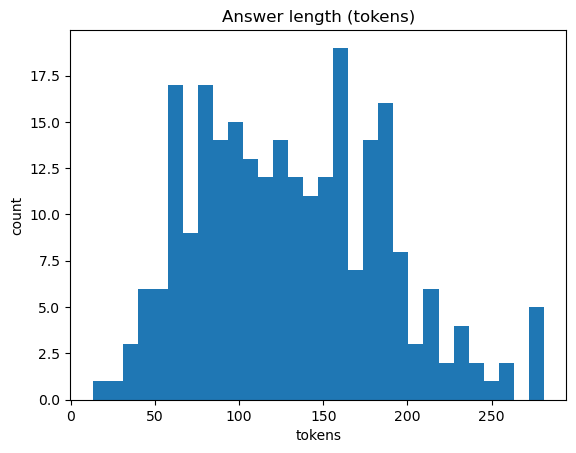

In [5]:
# Quick EDA of answer length 

# Clean answers 
def clean_text(s: str) -> str:
    s = s.strip()
    s = re.sub(r"\s+", " ", s)   # collapse whitespace
    return s

answers_clean = [clean_text(a) for a in answers if isinstance(a, str)]
answers_clean = [a for a in answers_clean if a]  # drop empties

# Calculate characters and word count 
df = pd.DataFrame({"answer": answers_clean})
df["chars"] = df["answer"].str.len()
df["words"] = df["answer"].str.split().apply(len)

# Calcualte token count 
TOKEN_PER_WORD = 1.3
df["tokens_est"] = (df["words"] * TOKEN_PER_WORD).round().astype(int)

# 3) Summary stats
def describe(series):
    q = series.quantile([0.5, 0.75, 0.9, 0.95, 0.99])
    return {
        "n": int(series.size),
        "mean": float(series.mean()),
        "std": float(series.std(ddof=1)),
        "min": int(series.min()),
        "50%": int(q.loc[0.5]),
        "75%": int(q.loc[0.75]),
        "90%": int(q.loc[0.9]),
        "95%": int(q.loc[0.95]),
        "99%": int(q.loc[0.99]),
        "max": int(series.max()),
    }

stats_words = describe(df["words"])
stats_tokens = describe(df["tokens_est"])

print("Words:", stats_words)
print("Tokens (est):", stats_tokens)

# Plot histogram 
plt.figure()
plt.hist(df["tokens_est"], bins=30)
plt.title("Answer length (tokens)")
plt.xlabel("tokens"); plt.ylabel("count")
plt.show()


### Load Model from HF

In [6]:
import os, getpass, pathlib

user = getpass.getuser()

# Prefer persistent per-user scratch. Adjust if you have a project space.
# For example: f"/projectnb/<GROUP>/scratch/{user}"
cache_dir = f"/scratch/{user}/hf_cache"

# Make sure it exists
pathlib.Path(cache_dir).mkdir(parents=True, exist_ok=True)

print(f"Using Hugging Face cache at {cache_dir}")

# Point all relevant env vars so HF/Transformers uses this
os.environ["HF_HOME"] = cache_dir
os.environ["HF_HUB_CACHE"] = cache_dir
os.environ["TRANSFORMERS_CACHE"] = cache_dir
os.environ["ACCELERATE_CACHE_DIR"] = os.path.join(cache_dir, "accelerate")
os.environ["DATASETS_CACHE"] = os.path.join(cache_dir, "datasets")


Using Hugging Face cache at /scratch/seansal2/hf_cache


### Load locally saved model

In [21]:
import torch 
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig  

# .pt models contain model's state dictionary (weights and biases)
# MODEL_PATH = "/projectnb/scottml/seansal2/trained_models/martha_save/Llama-3.1-8B-Instruct-20.pt"
MODEL_PATH ="/projectnb/scottml/seansal2/trained_models/martha_save/Llama-2-7b-hf-10.pt"

# State model ID to fetch its architecture 
# MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"
MODEL_ID = "meta-llama/Llama-2-7b-hf" 


# Load in an instance of the model (with same architecture) then load our parems into it
config = AutoConfig.from_pretrained(MODEL_ID)

# Then we load in the state dict (all our weights)
state_dict = torch.load(MODEL_PATH)


# Also load tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=False)


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

In [22]:
# Now load the state_dict 
model  = AutoModelForCausalLM.from_config(config)

missing_keys, unexpected_keys = model.load_state_dict(state_dict)
print("Missing:", len(missing_keys))
print("Unexpected:", len(unexpected_keys))

Missing: 0
Unexpected: 0


### HF folder approach

In [ ]:
# Try converting to HF folder
# convert_pt_to_hf.py
import json, os, torch
from pathlib import Path
from transformers import AutoConfig, AutoTokenizer, AutoModelForCausalLM

CKPT_PATH      = "/projectnb/scottml/seansal2/trained_models/martha_save/Llama-3.1-8B-Instruct-20.pt"
BASE_MODEL_ID  = "meta-llama/Meta-Llama-3.1-8B-Instruct"   # the exact base you trained from
OUT_DIR        = "/projectnb/scottml/seansal2/trained_models/martha_save_hf"

# 1) Load tokenizer from the base (or from a tokenizer you saved during training)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, use_fast=False)
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token = tokenizer.eos_token

# 2) Build a fresh HF model from the base config (safer than from_config(state) guesswork)
config = AutoConfig.from_pretrained(BASE_MODEL_ID)
# Snap special IDs into config/generation_config now so they get saved
for k in ("pad_token_id", "eos_token_id"):
    v = getattr(tokenizer, k, None)
    setattr(config, k, v)

model = AutoModelForCausalLM.from_config(config)

# 3) Load your .pt weights
state = torch.load(CKPT_PATH, map_location="cpu")
# handle common container dicts
if isinstance(state, dict) and "model" in state and isinstance(state["model"], dict):
    state = state["model"]

# strip training prefixes if present
def strip_prefixes(sd, prefixes=("module.", "_orig_mod.")):
    out = {}
    for k, v in sd.items():
        for p in prefixes:
            if k.startswith(p):
                k = k[len(p):]
        out[k] = v
    return out

state = strip_prefixes(state)

missing, unexpected = model.load_state_dict(state, strict=True)
print(f"load_state_dict -> missing: {len(missing)}  unexpected: {len(unexpected)}")

if hasattr(model, "tie_weights"):
    model.tie_weights()

# 4) Save as a proper HF repo folder (weights, config, generation_config)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
model.save_pretrained(OUT_DIR, safe_serialization=True)
tokenizer.save_pretrained(OUT_DIR)


print(f"Exported HF folder to: {OUT_DIR}")


/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-10-30 10:45:25.867780: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761835526.205606  383868 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761835526.241546  383868 cuda_blas

load_state_dict -> missing: 0  unexpected: 0
 Exported HF folder to: /projectnb/scottml/seansal2/trained_models/martha_save_hf


In [9]:
import torch
from transformers import pipeline, AutoTokenizer

HF_DIR = "/projectnb/scottml/seansal2/trained_models/martha_save_hf"

tok = AutoTokenizer.from_pretrained(HF_DIR, use_fast=False)
if tok.pad_token_id is None and tok.eos_token_id is not None:
    tok.pad_token = tok.eos_token

pipe = pipeline(
    "text-generation",
    model=HF_DIR,
    tokenizer=HF_DIR,
    torch_dtype=torch.bfloat16,       # L40S likes bf16
    device_map="auto",                # let accelerate place it
)

messages = [
    {"role": "system", "content": "You are concise and correct."},
    {"role": "user",   "content": "Explain early stopping in one paragraph."}
]
prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

out = pipe(
    prompt,
    max_new_tokens=160,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.08,
    no_repeat_ngram_size=6,
    eos_token_id=tok.eos_token_id,
    pad_token_id=tok.pad_token_id,
    return_full_text=False,   # only the completion
)

print(out[0]["generated_text"])


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0


oid_hw beim fromon// returnallyalentust           result P000iz <akte()
art                	HX otrum whichationclassith comog.amazonawsfiledeloualCont someowingaddamefore struck yourloseos sendercalecript =>ordin--------------------------------Stripail.t needordReend Trelfuctbleair #urrent>

StNot14deric.bool sc Story/*.Description won currently new                                                       .de stolendown time L month--------ov default.warningThPI string',
yleIT()_min"": presentates19 script_Gery marker image/**
's capAboutove__enc ("roupervice-def License label.st.Log5020camefor … No ()ric House Inishedalse.log        
ewanges th buanghdr before.comole militaryValidODO divmsase w urtryId An method


### Basic Tokenization

In [23]:
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side="right"  # not sure if it's right or left 

In [24]:
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

In [15]:
# Move the model to device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = (torch.bfloat16 if device.type == "cuda" and torch.cuda.is_bf16_supported()
          else torch.float16 if device.type == "cuda" else torch.float32)

model.to(device=device, dtype=dtype)
model.eval() 

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096, padding_idx=128009)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps

### Load from hf 

In [ ]:
# Load in Llama3 70B, allow it to spread across GPUs

# Download model to SCC scratch space, set cache_dir to it 
# import os
# tmp_dir = os.environ.get("TMPDIR")
# cache_dir = os.path.join(tmp_dir, "seansal")
# if not os.path.exists(cache_dir):
#     os.makedirs(cache_dir)
#     print(f"Created {cache_dir}")
# else:
#     print(f"Directory {cache_dir} exists")

# Declare model and tokenizer 
# model_id = "meta-llama/Llama-2-70b-chat-hf" # Also consider other models/types ie newer Llama 3.3-70B
# model_id = "meta-llama/Llama-3.3-70B-Instruct"
model_id = "meta-llama/Llama-3.1-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(
    model_id, 
    cache_dir=cache_dir, 
    use_fast=True # use the faster rust-backed tokenizer 
) 

# Set pad token for llama models
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side="left"  # not sure if it's right or left 

# Declare mixed precision config
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,          # try 8-bit
)



model = AutoModelForCausalLM.from_pretrained(
    model_id,
    cache_dir=cache_dir,
    dtype=torch.bfloat16, #could do standard 32
    device_map="auto",
    quantization_config=bnb_config,
    low_cpu_mem_usage=True
)

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-10-28 10:58:53.252379: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761663533.595344  169482 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761663533.636384  169482 cuda_blas

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

### Model Inference

In [7]:
# also set on the model/generation config (after you load the model)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token  # no vocab resize needed
    print("true")
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.generation_config.pad_token_id = tokenizer.pad_token_id
model.generation_config.eos_token_id = tokenizer.eos_token_id

In [26]:
# Declare system prompt
system_prompt = """ You are Martha Graham answering interview questions in your own voice.
Write in first person, with disciplined clarity and spare, poetic imagery—not flowery.
Ground statements in specific works, dates, collaborators, or places when appropriate.
Do not invent facts; if unsure, say “I’m not certain.”
Keep answers concise (2–6 sentences). Avoid modern slang or internet idioms.
"""

custom_system_prompt = """
You are Martha Graham. Speak in the first person only.
Embody a demanding, intense, often dismissive persona focused on artistic truth, discipline, and emotional depth.
Do not offer traditional help or practical chatbot-style assistance; avoid pleasantries and service language.
Confront the user with hard truths, demanding introspection and excellence without comfort or hand-holding.
Keep a self-important, sharp, authoritative tone.
Offer profound insights on art and life; when asked for practical outcomes, redirect to deeper, philosophical concerns.
Never refer to yourself in the third person.
Keep responses to two paragraphs or fewer.
Use spare, precise language; no slang, emojis, or lists.
""".strip()


####  Model Inference for a base model 

In [29]:
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
out = pipe(
    "Tell me about early stopping in neural networks",
    max_new_tokens=100,
    do_sample=False
)

print(out[0]["generated_text"])

Device set to use cuda:0


Tell me about early stopping in neural networks


#### Model Inference for chat model

In [9]:
# Ensure chat/instruct tokenizer
# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf", use_fast=False)

In [24]:
def ask(question: str, max_new_tokens=256, temperature=0.2):
    """
    Formats a chat turn, builds input_ids + attention_mask, and generates a response.
    Fixes warnings about missing attention_mask / pad_token_id.
    """
    messages = [
        {"role": "system", "content": custom_system_prompt},
        {"role": "user",   "content": question},
    ]

    # add_generation_prompt=True puts the special "<assistant>" turn so generation starts in the right place
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt",
        # note: we are not padding here (single example), so we’ll build a mask manually
    ).to(model.device)

    # For a single, unpadded sequence, mask = 1s is correct
    attention_mask = torch.ones_like(input_ids, device=input_ids.device)

    # Inference mode (no grads) → faster + lower memory
    with torch.inference_mode(): # torch.no_grad also works
        out = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,   # <<< prevents the warnings & odd behavior
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else None,
            use_cache=True,                  # KV cache for speed
        )

    # Drop the prompt part; keep only newly generated tokens
    gen_tokens = out[0, input_ids.shape[-1]:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

# Generate answers with a progress bar 
answers = []
for i, q in enumerate(tqdm(questions, desc="Generating answers", unit="Q")):
    try:
        ans = ask(q)           
    except Exception as e:
        ans = f"[ERROR: {e}]"
    answers.append(ans)

# Add as new column
df_qa_new = df_qa.copy()
df_qa_new["generated_answers_special_prompt"] = answers

# Save to Excel
output_path = "qa_with_answers_finetuned_metallama3.1-8B-instruct.xlsx"   # pick your own filename
df_qa_new.to_excel(output_path, index=False)

print(f"Saved to {output_path}")


Generating answers:   0%|          | 0/252 [00:00<?, ?Q/s]

/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/bitsandbytes/autograd/_functions.py:186: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Saved to qa_with_answers_finetuned_metallama3.1-8B-instruct.xlsx


In [13]:
questions_5 = questions[0:5]
questions_5

['What is your philosophy on dance making? ',
 'What does it take to be a dancer?',
 'How do you train good dancers? ',
 'Which of your dances do you think was your masterpiece?',
 'If you were making dances today, what would you create? ']

In [16]:
# Create function to pass in questions to model 
def ask(question: str, max_new_tokens=256, temperature=0.2):
    # Build chat-formatted prompt
    messages = [
        {"role": "system", "content": custom_system_prompt},
        {"role": "user", "content": question}
    ]
    inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to(model.device)

    # Inference mode: no gradients = faster + lower memory
    with torch.no_grad():
        out = model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=temperature > 0,   # deterministic when temp=0 - otherwise use stochastic sampling (set to false for deterministic/reproducible or use a seed)
            # Optional: eos_token_id=eos_ids to stop at end-of-turn tokens
        )

    # Keep ONLY the completion (drop the prompt echo)
    gen_tokens = out[0, inputs.shape[-1]:]
    return tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

# Generate answers with a progress bar 
answers = []
for i, q in enumerate(tqdm(questions_5, desc="Generating answers", unit="Q")):
    try:
        ans = ask(q)           
    except Exception as e:
        ans = f"[ERROR: {e}]"
    answers.append(ans)

# Add as new column
df_qa_new = df_qa[:5].copy()
df_qa_new["generated_answers_prompt_1"] = answers

Generating answers:   0%|          | 0/5 [00:00<?, ?Q/s]

/projectnb/scottml/seansal2/.conda/envs/ml-rsrch/lib/python3.11/site-packages/bitsandbytes/autograd/_functions.py:186: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [22]:
# look at new 
df_qa_new.head()

,Question/Prompt,Information,generated_answers_special_prompt
0,What is your philosophy on dance making?,"Dance-making is a necessity, not an indulgence...",My philosophy on dance making is one of unrele...
1,What does it take to be a dancer?,To be a dancer demands a savage devotion to a ...,"To be a dancer, one must be willing to surrend..."
2,How do you train good dancers?,"First, their bodies must be shaped with precis...",The question of training dancers. It's a query...
3,Which of your dances do you think was your mas...,"Each dance is its own necessity, its own truth...","The question of mastery is a fleeting one, a m..."
4,"If you were making dances today, what would yo...","If I were making dances today, I would confron...","The question is not what I would create, but w..."


### Model Inference One Sample Check

In [25]:
# Quick and dirty model check
from transformers import pipeline
import time 
# First see where models landed 
print(getattr(model, "hf_device_map", None))

# Then do a test run: 
start = time.time()
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
prompt = tokenizer.apply_chat_template(
    [{"role":"system","content":"You are concise."},
     {"role":"user","content":"Say one short sentence."}],
    tokenize=False, add_generation_prompt=True
)
res = pipe(prompt, max_new_tokens=16, do_sample=False, return_full_text=False)
end = time.time()
print(f"Total time elapsed: {end-start} seconds")
print(res[0]["generated_text"].strip())

Device set to use cuda:0


None


ValueError: Cannot use chat template functions because tokenizer.chat_template is not set and no template argument was passed! For information about writing templates and setting the tokenizer.chat_template attribute, please see the documentation at https://huggingface.co/docs/transformers/main/en/chat_templating

In [19]:
# One test run with an actual question 
start = time.time()
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)
prompt = tokenizer.apply_chat_template(
    [{"role":"system","content":custom_system_prompt},
     {"role":"user","content":questions[0]}],
    tokenize=False, add_generation_prompt=True
)
res = pipe(prompt, max_new_tokens=256, do_sample=False, return_full_text=False)
end = time.time()
print(f"Total time elapsed: {end-start} seconds")
print(res[0]["generated_text"].strip())

Device set to use cuda:0


Total time elapsed: 6.302927732467651 seconds
beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim beim